# NEMCast — table inspection

One section per table. Each shows shape, dtypes, first 5 rows, and a numeric summary.

Run from `notebooks/`, so paths are relative (`../data/...`).

**The four tables:**

| File | What it is | Timing |
|---|---|---|
| `dispatchprice` | Actual cleared prices | After the interval |
| `dispatchregionsum` | Actual regional physical state | After the interval |
| `predispatch/` | AEMO's forecast prices, every vintage | Before the interval |
| `predispatch_regionsum/` | AEMO's forecast demand & renewables | Before the interval |

In [3]:
import pandas as pd
from pathlib import Path

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 200)

INTERIM = Path('../data/interim')

def inspect(df, name):
    print(f'=== {name} ===')
    print(f'shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
    if 'SETTLEMENTDATE' in df.columns:
        print(f'range: {df.SETTLEMENTDATE.min()}  ->  {df.SETTLEMENTDATE.max()}')
    elif 'DATETIME' in df.columns:
        print(f'range: {df.DATETIME.min()}  ->  {df.DATETIME.max()}')
    print()
    display(pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'nulls': df.isna().sum(),
        'distinct': df.nunique(),
    }))
    print('\nfirst 5 rows:')
    display(df.head())

---
## 1. DISPATCHPRICE — actual cleared prices

The target variable. `RRP` is the Regional Reference Price: the offer price of the marginal unit.
The other eight `*RRP` columns are FCAS prices, co-optimised in the same dispatch run.

In [4]:
price = pd.read_parquet(INTERIM / 'dispatchprice.parquet')
inspect(price, 'DISPATCHPRICE')

=== DISPATCHPRICE ===
shape: 1,883,520 rows x 13 cols
range: 2023-01-01 00:05:00  ->  2026-08-01 00:00:00



,dtype,nulls,distinct
SETTLEMENTDATE,datetime64[ns],0,376704
REGIONID,object,0,5
INTERVENTION,int64,0,1
RRP,float64,0,989132
RAISE6SECRRP,float64,0,20408
RAISE60SECRRP,float64,0,9263
RAISE5MINRRP,float64,0,1942
RAISEREGRRP,float64,0,60355
LOWER6SECRRP,float64,0,25706
LOWER60SECRRP,float64,0,16801



first 5 rows:


,SETTLEMENTDATE,REGIONID,INTERVENTION,RRP,RAISE6SECRRP,RAISE60SECRRP,RAISE5MINRRP,RAISEREGRRP,LOWER6SECRRP,LOWER60SECRRP,LOWER5MINRRP,LOWERREGRRP,PRICE_STATUS
0,2023-01-01 00:05:00,NSW1,0,140.39955,0.39,0.86,0.5,5.45,0.39,0.86,0.39,3.7,FIRM
1,2023-01-01 00:05:00,QLD1,0,139.73017,0.39,0.86,0.5,5.45,0.39,0.86,0.39,3.7,FIRM
2,2023-01-01 00:05:00,SA1,0,127.57100,0.39,0.86,0.5,5.45,0.39,0.86,0.39,3.7,FIRM
3,2023-01-01 00:05:00,TAS1,0,450.10000,0.39,0.86,0.5,5.45,0.39,0.86,0.39,3.7,FIRM
4,2023-01-01 00:05:00,VIC1,0,129.50841,0.39,0.86,0.5,5.45,0.39,0.86,0.39,3.7,FIRM


In [5]:
price.describe().T

,count,mean,min,25%,50%,75%,max,std
SETTLEMENTDATE,1883520,2024-10-16 00:02:29.999998464,2023-01-01 00:05:00,2023-11-24 00:03:45,2024-10-16 00:02:30,2025-09-08 00:01:15,2026-08-01 00:00:00,NaN
INTERVENTION,1883520.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RRP,1883520.0,87.215467,-1000.0,19.19,72.97378,113.602675,23200.0,380.45739
RAISE6SECRRP,1883520.0,4.696554,0.0,0.1,0.38,0.72,20300.0,167.456548
RAISE60SECRRP,1883520.0,1.582761,0.0,0.1,0.38,0.39,20300.0,63.46168
RAISE5MINRRP,1883520.0,0.359045,0.0,0.1,0.26,0.39,20290.0,24.347489
RAISEREGRRP,1883520.0,9.808018,0.0,3.53342,6.0,9.98,20300.0,89.282794
LOWER6SECRRP,1883520.0,2.156792,0.0,0.03,0.34,0.39,20300.0,113.420778
LOWER60SECRRP,1883520.0,2.01454,0.0,0.15,0.38,0.45,17500.0,48.282592
LOWER5MINRRP,1883520.0,0.725255,0.0,0.01,0.15,0.39,11166.64618,10.895062


---
## 2. DISPATCHREGIONSUM — actual regional state

The physical picture behind each price. **Most of this is dispatch output**, produced by the same
solve that set the price — so it's leakage if used contemporaneously. The exceptions are the
bid-derived and forecast columns (`AVAILABLEGENERATION`, `AVAILABLELOAD`, `UIGF`).

In [6]:
regionsum = pd.read_parquet(INTERIM / 'dispatchregionsum.parquet')
inspect(regionsum, 'DISPATCHREGIONSUM')

=== DISPATCHREGIONSUM ===
shape: 1,883,520 rows x 27 cols
range: 2023-01-01 00:05:00  ->  2026-08-01 00:00:00



,dtype,nulls,distinct
SETTLEMENTDATE,datetime64[ns],0,376704
REGIONID,object,0,5
DISPATCHINTERVAL,int64,0,376704
INTERVENTION,int64,0,1
TOTALDEMAND,float64,0,689311
AVAILABLEGENERATION,float64,0,1872975
AVAILABLELOAD,int64,0,2657
DEMANDFORECAST,float64,0,180324
DISPATCHABLEGENERATION,float64,0,646998
DISPATCHABLELOAD,float64,0,57812



first 5 rows:


,SETTLEMENTDATE,REGIONID,DISPATCHINTERVAL,INTERVENTION,TOTALDEMAND,AVAILABLEGENERATION,AVAILABLELOAD,DEMANDFORECAST,DISPATCHABLEGENERATION,DISPATCHABLELOAD,NETINTERCHANGE,EXCESSGENERATION,LOWER5MINLOCALDISPATCH,LOWER60SECLOCALDISPATCH,LOWER6SECLOCALDISPATCH,RAISE5MINLOCALDISPATCH,RAISE60SECLOCALDISPATCH,RAISE6SECLOCALDISPATCH,INITIALSUPPLY,CLEAREDSUPPLY,LOWERREGLOCALDISPATCH,RAISEREGLOCALDISPATCH,TOTALINTERMITTENTGENERATION,DEMAND_AND_NONSCHEDGEN,UIGF,SEMISCHEDULE_CLEAREDMW,SEMISCHEDULE_COMPLIANCEMW
0,2023-01-01 00:05:00,NSW1,20221231241,0,6906.63,11175.80624,57,-0.90234,6337.20,0.0,-569.44,0.0,52.00,90.00,84.00,69.00,106.00,61.00,6922.25439,6918.91,89.0,74.0,38.68982,6957.59982,1006.80624,1006.80624,0.0
1,2023-01-01 00:05:00,QLD1,20221231241,0,5718.46,8311.67401,75,7.95361,5830.28,0.0,111.82,0.0,47.00,47.00,47.00,52.00,125.00,128.00,5717.90479,5717.83,5.0,24.0,78.18375,5796.01375,472.67401,472.67400,25.0
2,2023-01-01 00:05:00,SA1,20221231241,0,1443.65,2881.27204,146,-4.16825,1458.27,0.0,14.62,0.0,80.68,153.00,93.32,89.00,105.77,127.00,1448.56140,1443.26,19.0,88.0,0.00000,1443.26000,1054.27204,1054.27205,0.0
3,2023-01-01 00:05:00,TAS1,20221231241,0,1001.74,2320.68091,0,-1.46765,1209.37,0.0,207.63,0.0,28.00,0.00,0.00,117.46,160.50,215.27,1013.73779,1005.27,40.0,10.0,146.67966,1151.94966,198.68091,198.68091,0.0
4,2023-01-01 00:05:00,VIC1,20221231241,0,4676.57,8648.54087,125,-39.37061,4936.54,0.0,259.97,0.0,119.00,181.06,153.00,137.42,122.00,88.00,4739.07373,4686.39,57.0,24.0,43.52300,4729.91300,513.54087,513.54087,0.0


In [7]:
regionsum.describe().T

,count,mean,min,25%,50%,75%,max,std
SETTLEMENTDATE,1883520,2024-10-16 00:02:29.999999744,2023-01-01 00:05:00,2023-11-24 00:03:45,2024-10-16 00:02:30,2025-09-08 00:01:15,2026-08-01 00:00:00,NaN
DISPATCHINTERVAL,1883520.0,20243864043.327732,20221231241.0,20231123240.75,20241015240.5,20250907240.25,20260731240.0,10436383.441137
INTERVENTION,1883520.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TOTALDEMAND,1883520.0,4186.604963,-311.1,1279.87,4500.465,6441.4225,13763.96,2764.715495
AVAILABLEGENERATION,1883520.0,7402.144864,1278.63776,2470.531902,8849.50081,10855.051812,18619.8176,4332.650473
AVAILABLELOAD,1883520.0,409.308126,0.0,58.0,294.0,597.0,2878.0,473.397438
DEMANDFORECAST,1883520.0,-0.062193,-379.0,-15.0,-2.0,9.0,356.0,27.781137
DISPATCHABLEGENERATION,1883520.0,4283.579032,75.71,1214.44,5202.575,6581.28,13620.93,2811.129385
DISPATCHABLELOAD,1883520.0,77.243643,0.0,0.0,0.0,45.0,2429.21,184.433389
NETINTERCHANGE,1883520.0,19.740658,-2556.44,-401.6925,0.0,396.37,2583.34,601.204915


---
## 3. PREDISPATCH PRICE — AEMO's forecast prices

Partitioned by month. Reading one month here to keep memory flat.

**Two time columns, and the distinction is the whole point:**
- `PREDISPATCH_RUN_DATETIME` — when the forecast was made
- `DATETIME` — the interval being forecast

Every target interval appears in ~40 rows, one per run. This is what lets you filter to
"forecasts available at 12:30" without using information from the future.

In [8]:
pdp_files = sorted((INTERIM / 'predispatch').glob('*.parquet'))
print(f'{len(pdp_files)} monthly files:')
for f in pdp_files:
    print(' ', f.name)

19 monthly files:
  predispatch_price_202301.parquet
  predispatch_price_202302.parquet
  predispatch_price_202303.parquet
  predispatch_price_202304.parquet
  predispatch_price_202305.parquet
  predispatch_price_202306.parquet
  predispatch_price_202307.parquet
  predispatch_price_202308.parquet
  predispatch_price_202309.parquet
  predispatch_price_202310.parquet
  predispatch_price_202311.parquet
  predispatch_price_202312.parquet
  predispatch_price_202401.parquet
  predispatch_price_202402.parquet
  predispatch_price_202403.parquet
  predispatch_price_202404.parquet
  predispatch_price_202405.parquet
  predispatch_price_202406.parquet
  predispatch_price_202407.parquet


In [9]:
pdp = pd.read_parquet(pdp_files[0])
inspect(pdp, 'PREDISPATCH PRICE (2023-01)')

=== PREDISPATCH PRICE (2023-01) ===
shape: 396,580 rows x 5 cols
range: 2023-01-01 04:30:00  ->  2023-02-01 00:00:00



,dtype,nulls,distinct
PREDISPATCH_RUN_DATETIME,datetime64[ns],0,1432
DATETIME,datetime64[us],0,1480
REGIONID,object,0,5
RRP,float32,0,225333
INTERVENTION,int8,0,1



first 5 rows:


,PREDISPATCH_RUN_DATETIME,DATETIME,REGIONID,RRP,INTERVENTION
0,2023-01-01 04:30:00,2023-01-01 04:30:00,NSW1,80.019997,0
1,2023-01-01 04:30:00,2023-01-01 05:00:00,NSW1,80.019997,0
2,2023-01-01 04:30:00,2023-01-01 05:30:00,NSW1,80.019997,0
3,2023-01-01 04:30:00,2023-01-01 06:00:00,NSW1,80.010002,0
4,2023-01-01 04:30:00,2023-01-01 06:30:00,NSW1,38.995041,0


In [10]:
# The vintage structure: one interval, forecast many times.
one = pdp[(pdp.REGIONID == 'SA1') & (pdp.DATETIME == pdp.DATETIME.iloc[500])]
print(f'interval {pdp.DATETIME.iloc[500]} forecast {len(one)} times:\n')
display(one[['PREDISPATCH_RUN_DATETIME', 'DATETIME', 'RRP']]
        .sort_values('PREDISPATCH_RUN_DATETIME'))

interval 2023-01-01 18:00:00 forecast 28 times:



,PREDISPATCH_RUN_DATETIME,DATETIME,RRP
123,2023-01-01 04:30:00,2023-01-01 18:00:00,283.886841
360,2023-01-01 05:00:00,2023-01-01 18:00:00,276.630005
592,2023-01-01 05:30:00,2023-01-01 18:00:00,262.772034
819,2023-01-01 06:00:00,2023-01-01 18:00:00,267.326569
1041,2023-01-01 06:30:00,2023-01-01 18:00:00,264.149750
1258,2023-01-01 07:00:00,2023-01-01 18:00:00,253.483109
1470,2023-01-01 07:30:00,2023-01-01 18:00:00,207.223816
1677,2023-01-01 08:00:00,2023-01-01 18:00:00,210.744186
1879,2023-01-01 08:30:00,2023-01-01 18:00:00,317.285736
2076,2023-01-01 09:00:00,2023-01-01 18:00:00,298.074829


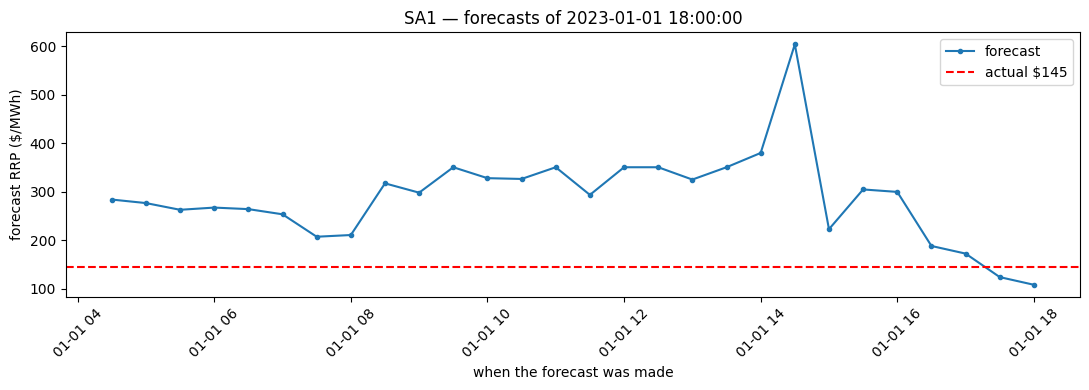

In [14]:
import matplotlib.pyplot as plt

target = pdp.DATETIME.iloc[500]
one = (pdp[(pdp.REGIONID=='SA1') & (pdp.DATETIME==target)]
       .sort_values('PREDISPATCH_RUN_DATETIME'))

actual = price.loc[(price.REGIONID=='SA1') &
                   (price.SETTLEMENTDATE==target), 'RRP']

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(one.PREDISPATCH_RUN_DATETIME, one.RRP, marker='o', ms=3,
        label='forecast')
if len(actual):
    ax.axhline(actual.iloc[0], color='r', ls='--',
               label=f'actual ${actual.iloc[0]:.0f}')
ax.set_xlabel('when the forecast was made')
ax.set_ylabel('forecast RRP ($/MWh)')
ax.set_title(f'SA1 — forecasts of {target}')
ax.legend()
plt.xticks(rotation=45); plt.tight_layout()

---
## 4. PREDISPATCH REGIONSUM — AEMO's forecast demand & renewables

Same vintage structure. `SS_WIND_UIGF` and `SS_SOLAR_UIGF` split the intermittent forecast —
worth keeping separate, since solar is predictable and diurnal while wind is volatile and
can collapse at any hour.

In [11]:
pdr_files = sorted((INTERIM / 'predispatch_regionsum').glob('*.parquet'))
pdr = pd.read_parquet(pdr_files[0])
inspect(pdr, 'PREDISPATCH REGIONSUM (2023-01)')

=== PREDISPATCH REGIONSUM (2023-01) ===
shape: 396,580 rows x 10 cols
range: 2023-01-01 04:30:00  ->  2023-02-01 00:00:00



,dtype,nulls,distinct
PREDISPATCH_RUN_DATETIME,datetime64[ns],0,1432
DATETIME,datetime64[us],0,1480
REGIONID,object,0,5
INTERVENTION,int8,0,1
TOTALDEMAND,float32,0,253584
AVAILABLEGENERATION,float32,0,376351
AVAILABLELOAD,int16,0,217
UIGF,float32,0,360151
SS_SOLAR_UIGF,float32,0,155811
SS_WIND_UIGF,float32,0,332644



first 5 rows:


,PREDISPATCH_RUN_DATETIME,DATETIME,REGIONID,INTERVENTION,TOTALDEMAND,AVAILABLEGENERATION,AVAILABLELOAD,UIGF,SS_SOLAR_UIGF,SS_WIND_UIGF
0,2023-01-01 04:30:00,2023-01-01 04:30:00,NSW1,0,5821.029785,11000.146484,57,814.145996,0.000000,814.145996
1,2023-01-01 04:30:00,2023-01-01 05:00:00,NSW1,0,5751.669922,10969.994141,57,783.994019,0.000000,783.994019
2,2023-01-01 04:30:00,2023-01-01 05:30:00,NSW1,0,5782.450195,10944.619141,57,758.619019,20.421000,738.197998
3,2023-01-01 04:30:00,2023-01-01 06:00:00,NSW1,0,5784.200195,11138.632812,57,956.632996,276.528992,680.104004
4,2023-01-01 04:30:00,2023-01-01 06:30:00,NSW1,0,5751.370117,12058.948242,57,1280.947998,653.801025,627.146973


In [12]:
pdr.describe().T

,count,mean,min,25%,50%,75%,max,std
PREDISPATCH_RUN_DATETIME,396580,2023-01-16 02:11:30.624841984,2023-01-01 04:30:00,2023-01-08 16:00:00,2023-01-16 01:30:00,2023-01-23 14:00:00,2023-01-31 00:00:00,NaN
DATETIME,396580,2023-01-16 16:38:58.937919,2023-01-01 04:30:00,2023-01-09 04:30:00,2023-01-16 17:30:00,2023-01-24 02:30:00,2023-02-01 00:00:00,NaN
INTERVENTION,396580.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TOTALDEMAND,396580.0,4163.966309,228.399994,1229.017517,4499.399902,6419.507446,11085.459961,2698.883301
AVAILABLEGENERATION,396580.0,7236.552734,1525.560181,2349.882812,8775.508301,10017.419189,15300.548828,4270.57959
AVAILABLELOAD,396580.0,93.929742,0.0,47.0,75.0,138.0,833.0,102.026403
UIGF,396580.0,856.304504,0.0,269.137764,757.186005,1269.053986,3111.897949,674.597107
SS_SOLAR_UIGF,396580.0,335.383209,0.0,0.0,0.0,411.996498,2195.899902,589.927856
SS_WIND_UIGF,396580.0,520.921265,0.0,146.833,376.240997,842.47049,2654.649902,458.521484


---
## Cross-check: do the two forecast tables align?

They should join 1:1 on run time, interval, and region.

In [13]:
KEYS = ['PREDISPATCH_RUN_DATETIME', 'DATETIME', 'REGIONID']
j = pdp.merge(pdr, on=KEYS, how='inner', suffixes=('_price', '_sum'))
print(f'price:  {len(pdp):,}')
print(f'sum:    {len(pdr):,}')
print(f'joined: {len(j):,}')
j.head()

price:  396,580
sum:    396,580
joined: 396,580


,PREDISPATCH_RUN_DATETIME,DATETIME,REGIONID,RRP,INTERVENTION_price,INTERVENTION_sum,TOTALDEMAND,AVAILABLEGENERATION,AVAILABLELOAD,UIGF,SS_SOLAR_UIGF,SS_WIND_UIGF
0,2023-01-01 04:30:00,2023-01-01 04:30:00,NSW1,80.019997,0,0,5821.029785,11000.146484,57,814.145996,0.000000,814.145996
1,2023-01-01 04:30:00,2023-01-01 05:00:00,NSW1,80.019997,0,0,5751.669922,10969.994141,57,783.994019,0.000000,783.994019
2,2023-01-01 04:30:00,2023-01-01 05:30:00,NSW1,80.019997,0,0,5782.450195,10944.619141,57,758.619019,20.421000,738.197998
3,2023-01-01 04:30:00,2023-01-01 06:00:00,NSW1,80.010002,0,0,5784.200195,11138.632812,57,956.632996,276.528992,680.104004
4,2023-01-01 04:30:00,2023-01-01 06:30:00,NSW1,38.995041,0,0,5751.370117,12058.948242,57,1280.947998,653.801025,627.146973


---
## Notes

Add your column-by-column findings here as you work through them.

### DISPATCHPRICE
- `RRP` — target. Floor -$1,000, cap ~$20,300 (rises annually).
- `PRICE_STATUS` — `FIRM` means settled and unrevisable.
- `INTERVENTION` — already filtered to 0.

### DISPATCHREGIONSUM
- `DEMANDFORECAST` — a **delta** (±13 MW), not a level. Expected change over the interval.
- `UIGF` vs `SEMISCHEDULE_CLEAREDMW` — the gap is curtailment, and it's **caused by** price.
- `TOTALDEMAND` — operational demand, net of rooftop solar.

### PREDISPATCH
- Resolution is 30-minute, not 5-minute.
- `RRP1`..`RRP8` are demand-scenario sensitivities, not the main forecast.
